In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('./placement.csv')
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [3]:
df = df.drop_duplicates()
df.shape

(981, 3)

In [4]:
#checking outliers
num_col = df.select_dtypes(include = [np.number]).columns
for col in num_col:
    iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
    lower = df[col].quantile(0.25) - (1.5 * iqr)
    upper = df[col].quantile(0.75) + (1.5 * iqr)
    outliers = np.where(df[col] > upper, True, np.where(df[col] < lower, True, False))
    print(f"outliers in {col}: {outliers.sum()}")

outliers in cgpa: 8
outliers in placement_exam_marks: 15
outliers in placed: 0


In [5]:
X = df[["cgpa"]]
y = df['placement_exam_marks']
X.shape

(981, 1)

In [6]:
def initialize(dim):
  m=np.zeros(dim)
  b=0.0
  return m,b

In [7]:
def predict(X,m,b):
  return np.dot(X,m) +b

In [8]:
def compute_cost(y,y_pred):
  n=len(y)
  cost = (1/(2*n)) * np.sum(np.square(y_pred-y))
  return cost

In [9]:
def compute_gradient(X,y,y_pred,m,b,L):
  n=len(y)
  dm = np.dot(X.T,y_pred-y)/n
  db = np.sum(y_pred-y)/n

  m_new= m - L*dm
  b_new= b- L*db
  return m_new,b_new

In [10]:
def run(X,y,max_itr=100,L=0.0001):
  m,b = initialize(X.shape[1])

  cost_hist=[]
  prev_cost=float("inf")

  for itr in range(max_itr):
    y_pred = predict(X,m,b)
    cost = compute_cost(y,y_pred)
    cost_hist.append(cost)
    prev_cost=cost

    m,b = compute_gradient(X,y,y_pred,m,b,L)
  return m,b,cost_hist

In [11]:
m,b,cost_hist = run(X,y,150,0.001)

print("Weight:", m)
print("Bias:", b)
print("Final Cost:", cost_hist[-1])

Weight: [4.49525844]
Bias: 0.6859208937485396
Final Cost: 189.58077821455686


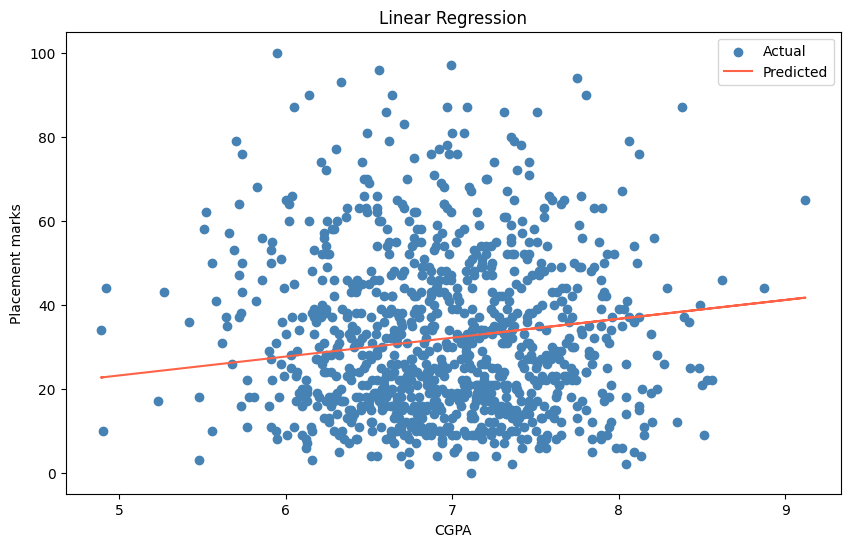

In [12]:
y_pred=predict(X,m,b)
plt.figure(figsize=(10,6))
plt.scatter(X,y,label="Actual",color="steelblue")
plt.plot(X,y_pred,label="Predicted",color="tomato")
plt.xlabel("CGPA")
plt.ylabel("Placement marks")
plt.title("Linear Regression")
plt.legend()
plt.show()

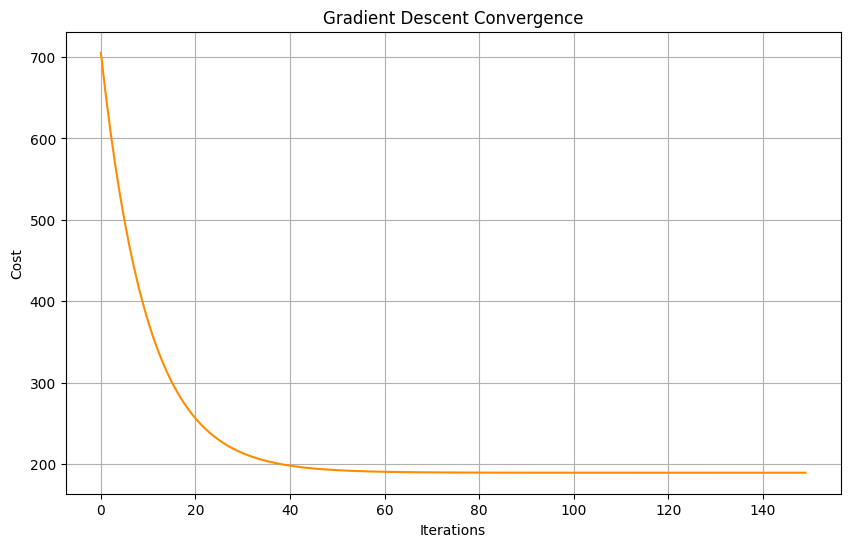

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(cost_hist,color='darkorange')

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.grid()

plt.show()